# Logistic Regression
## DA5401W - Data Analytics Lab
**Instructor:** Dr. Arun B Ayyar

---

## Table of Contents
1. [Why Logistic Regression?](#part-1)
2. [Logistic (Sigmoid) Function](#part-2)
3. [Maximum Likelihood Estimation](#part-3)
4. [Decision Boundaries](#part-4)
5. [Binary Classification — Practical Example](#part-5)
6. [Multi-class Classification](#part-6)
7. [Regularization in Logistic Regression](#part-7)
8. [Model Evaluation & Validation](#part-8)
9. [Assumptions & Diagnostics](#part-9)
10. [Summary & Key Takeaways](#summary)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.datasets import make_classification, make_blobs, load_iris, load_breast_cancer
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, accuracy_score, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
<a id='part-1'></a>
# Part 1: Why Logistic Regression?

## 1.1 The Classification Problem

In **classification**, the goal is to predict a **discrete class label** $y \in \{0, 1\}$ (binary) or $y \in \{0, 1, \ldots, K-1\}$ (multi-class) from input features $\mathbf{x}$.

## 1.2 Why Not Linear Regression?

Linear regression predicts $\hat{y} = \mathbf{w}^T\mathbf{x}$, which can take any value in $(-\infty, +\infty)$. For classification, we need outputs in $[0, 1]$ to represent probabilities. Additionally, linear regression is highly sensitive to outliers in the class labels.

| Issue | Linear Regression | Logistic Regression |
|-------|------------------|--------------------|
| **Output range** | $(-\infty, +\infty)$ | $(0, 1)$ |
| **Interpretation** | Continuous value | Probability |
| **Decision boundary** | Unbounded | Principled threshold |
| **Loss function** | MSE | Log-loss (cross-entropy) |
| **Outlier sensitivity** | High | Low |

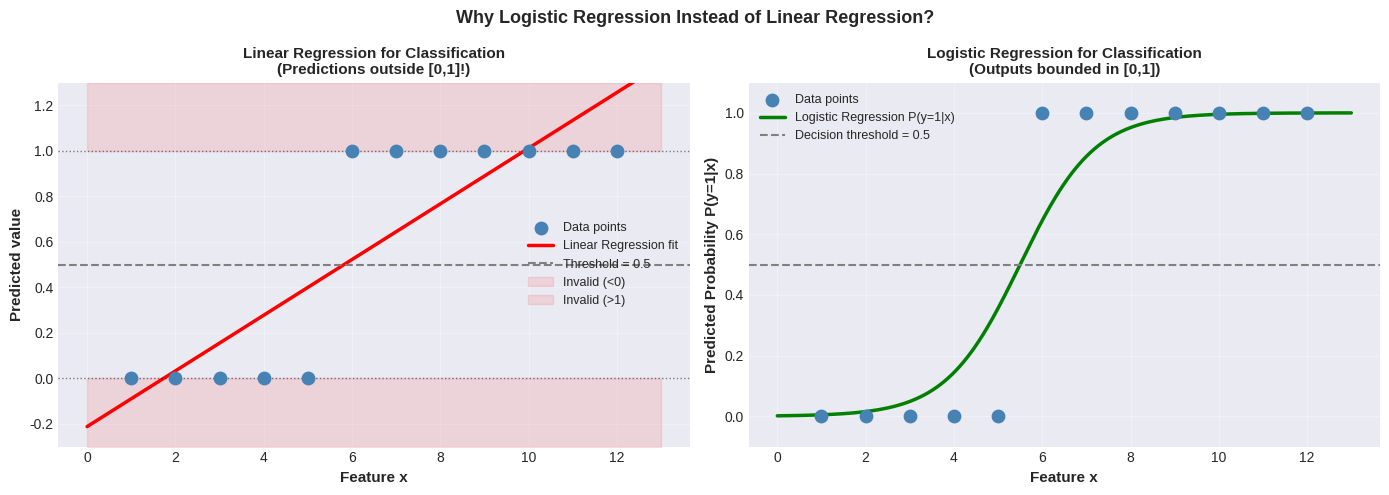

In [2]:
# Demonstrate why linear regression fails for classification
np.random.seed(42)
X_cls = np.array([1,2,3,4,5,6,7,8,9,10,11,12], dtype=float).reshape(-1,1)
y_cls = np.array([0,0,0,0,0,1,1,1,1,1,1,1], dtype=float)

lin_reg = LinearRegression().fit(X_cls, y_cls)
log_reg = LogisticRegression().fit(X_cls, y_cls)
X_plot = np.linspace(0, 13, 300).reshape(-1,1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_cls, y_cls, s=80, zorder=5, color='steelblue', label='Data points')
axes[0].plot(X_plot, lin_reg.predict(X_plot), 'r-', lw=2.5, label='Linear Regression fit')
axes[0].axhline(0.5, color='gray', ls='--', lw=1.5, label='Threshold = 0.5')
axes[0].axhline(0, color='k', ls=':', lw=1, alpha=0.5)
axes[0].axhline(1, color='k', ls=':', lw=1, alpha=0.5)
axes[0].fill_between(X_plot.ravel(), -0.3, 0, alpha=0.1, color='red', label='Invalid (<0)')
axes[0].fill_between(X_plot.ravel(), 1, 1.3, alpha=0.1, color='red', label='Invalid (>1)')
axes[0].set_xlabel('Feature x', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted value', fontsize=11, fontweight='bold')
axes[0].set_title('Linear Regression for Classification\n(Predictions outside [0,1]!)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_ylim(-0.3, 1.3); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_cls, y_cls, s=80, zorder=5, color='steelblue', label='Data points')
axes[1].plot(X_plot, log_reg.predict_proba(X_plot)[:,1], 'g-', lw=2.5, label='Logistic Regression P(y=1|x)')
axes[1].axhline(0.5, color='gray', ls='--', lw=1.5, label='Decision threshold = 0.5')
axes[1].set_xlabel('Feature x', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Probability P(y=1|x)', fontsize=11, fontweight='bold')
axes[1].set_title('Logistic Regression for Classification\n(Outputs bounded in [0,1])', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_ylim(-0.1, 1.1); axes[1].grid(True, alpha=0.3)

plt.suptitle('Why Logistic Regression Instead of Linear Regression?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-2'></a>
# Part 2: The Logistic (Sigmoid) Function

## 2.1 Mathematical Formulation

Logistic regression models the **conditional probability** of the positive class:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x}+b)}}$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the **sigmoid function**, which maps any real number to $(0,1)$.

## 2.2 Log-Odds (Logit) Interpretation

Taking the log of the odds ratio:

$$\log \frac{P(y=1\mid\mathbf{x})}{P(y=0\mid\mathbf{x})} = \mathbf{w}^T\mathbf{x} + b$$

The **log-odds** (logit) is a **linear function** of the input features. Each coefficient $w_j$ represents the change in log-odds for a one-unit increase in $x_j$.

| $z = \mathbf{w}^T\mathbf{x}$ | $\sigma(z)$ | Interpretation |
|-------------------------------|-------------|----------------|
| $z \to -\infty$ | $\to 0$ | Strongly predicts class 0 |
| $z = 0$ | $= 0.5$ | Decision boundary |
| $z \to +\infty$ | $\to 1$ | Strongly predicts class 1 |

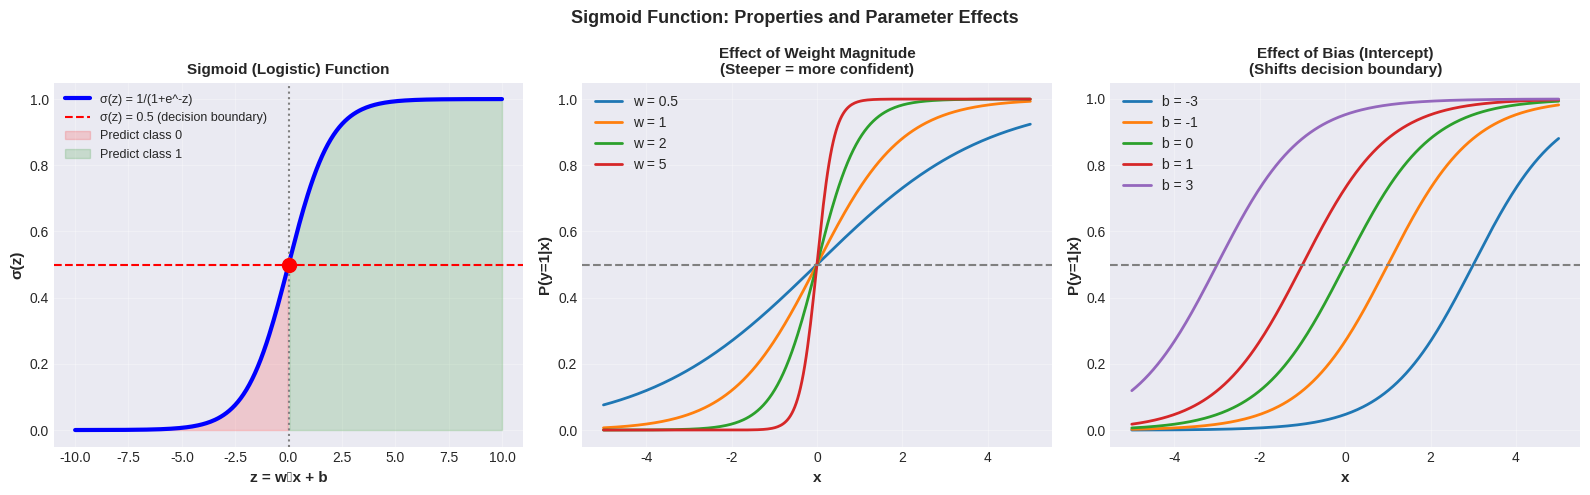

In [3]:
# Sigmoid function and effect of weights
z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sigmoid curve
axes[0].plot(z, sigmoid, 'b-', lw=3, label='σ(z) = 1/(1+e^-z)')
axes[0].axhline(0.5, color='red', ls='--', lw=1.5, label='σ(z) = 0.5 (decision boundary)')
axes[0].axvline(0, color='gray', ls=':', lw=1.5)
axes[0].scatter([0], [0.5], s=100, color='red', zorder=5)
axes[0].fill_between(z, 0, sigmoid, where=(z < 0), alpha=0.15, color='red', label='Predict class 0')
axes[0].fill_between(z, 0, sigmoid, where=(z >= 0), alpha=0.15, color='green', label='Predict class 1')
axes[0].set_xlabel('z = wᵀx + b', fontsize=11, fontweight='bold')
axes[0].set_ylabel('σ(z)', fontsize=11, fontweight='bold')
axes[0].set_title('Sigmoid (Logistic) Function', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Effect of weight magnitude
x_vals = np.linspace(-5, 5, 300)
for w in [0.5, 1, 2, 5]:
    axes[1].plot(x_vals, 1/(1+np.exp(-w*x_vals)), lw=2, label=f'w = {w}')
axes[1].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[1].set_xlabel('x', fontsize=11, fontweight='bold')
axes[1].set_ylabel('P(y=1|x)', fontsize=11, fontweight='bold')
axes[1].set_title('Effect of Weight Magnitude\n(Steeper = more confident)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

# Effect of bias (shift)
for b in [-3, -1, 0, 1, 3]:
    axes[2].plot(x_vals, 1/(1+np.exp(-(x_vals+b))), lw=2, label=f'b = {b}')
axes[2].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[2].set_xlabel('x', fontsize=11, fontweight='bold')
axes[2].set_ylabel('P(y=1|x)', fontsize=11, fontweight='bold')
axes[2].set_title('Effect of Bias (Intercept)\n(Shifts decision boundary)', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

plt.suptitle('Sigmoid Function: Properties and Parameter Effects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-3'></a>
# Part 3: Maximum Likelihood Estimation (MLE)

## 3.1 The Likelihood Function

For $N$ independent observations, the likelihood is:

$$L(\mathbf{w}) = \prod_{i=1}^{N} P(y_i \mid \mathbf{x}_i; \mathbf{w}) = \prod_{i=1}^{N} \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}$$

## 3.2 Log-Likelihood and Cross-Entropy Loss

Taking the negative log-likelihood gives the **binary cross-entropy loss**:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

This is minimized using **gradient descent**:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{N} \mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

## 3.3 Comparison: OLS vs MLE

| Aspect | OLS (Linear Regression) | MLE (Logistic Regression) |
|--------|------------------------|---------------------------|
| **Loss** | Mean Squared Error | Binary Cross-Entropy |
| **Solution** | Closed-form | Iterative (gradient descent) |
| **Output** | Continuous $\hat{y}$ | Probability $\hat{p} \in (0,1)$ |
| **Convexity** | Convex (unique solution) | Convex (unique solution) |

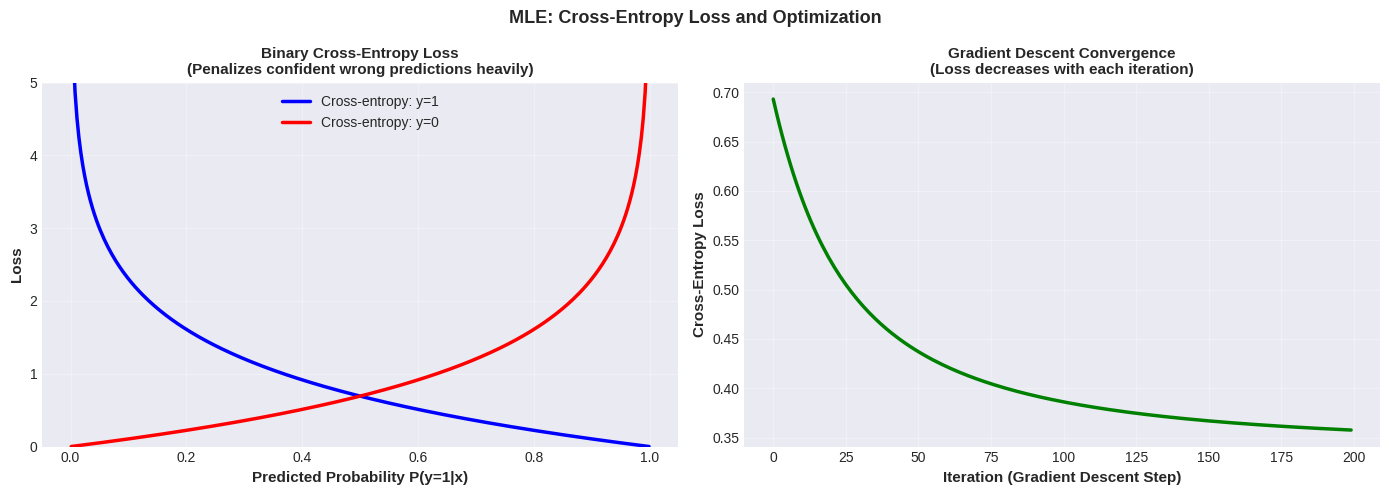

In [4]:
# Visualize cross-entropy loss vs MSE for classification
p_hat = np.linspace(0.001, 0.999, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-entropy loss for y=1 and y=0
ce_y1 = -np.log(p_hat)         # loss when true label = 1
ce_y0 = -np.log(1 - p_hat)    # loss when true label = 0
axes[0].plot(p_hat, ce_y1, 'b-', lw=2.5, label='Cross-entropy: y=1')
axes[0].plot(p_hat, ce_y0, 'r-', lw=2.5, label='Cross-entropy: y=0')
axes[0].set_xlabel('Predicted Probability P(y=1|x)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0].set_title('Binary Cross-Entropy Loss\n(Penalizes confident wrong predictions heavily)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].set_ylim(0, 5); axes[0].grid(True, alpha=0.3)

# Gradient descent convergence simulation
np.random.seed(42)
X_gd, y_gd = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=42)
sc = StandardScaler()
X_gd_s = sc.fit_transform(X_gd)

losses = []
w = np.zeros(X_gd_s.shape[1]); b = 0.0; lr = 0.1
for _ in range(200):
    z = X_gd_s @ w + b
    p = 1 / (1 + np.exp(-z))
    loss = -np.mean(y_gd * np.log(p+1e-9) + (1-y_gd) * np.log(1-p+1e-9))
    losses.append(loss)
    dw = X_gd_s.T @ (p - y_gd) / len(y_gd)
    db = np.mean(p - y_gd)
    w -= lr * dw; b -= lr * db

axes[1].plot(losses, 'g-', lw=2.5)
axes[1].set_xlabel('Iteration (Gradient Descent Step)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cross-Entropy Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Gradient Descent Convergence\n(Loss decreases with each iteration)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('MLE: Cross-Entropy Loss and Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-4'></a>
# Part 4: Decision Boundaries

## 4.1 What is a Decision Boundary?

The **decision boundary** is the set of points where $P(y=1 \mid \mathbf{x}) = 0.5$, i.e., where $\mathbf{w}^T\mathbf{x} + b = 0$. For logistic regression, this is always a **hyperplane** (a line in 2D, a plane in 3D), making it a **linear classifier**.

## 4.2 Visualizing Decision Boundaries

The decision boundary separates the feature space into two regions:
- **Region 1:** $\mathbf{w}^T\mathbf{x} + b > 0 \Rightarrow P(y=1) > 0.5 \Rightarrow$ predict class 1
- **Region 0:** $\mathbf{w}^T\mathbf{x} + b < 0 \Rightarrow P(y=1) < 0.5 \Rightarrow$ predict class 0

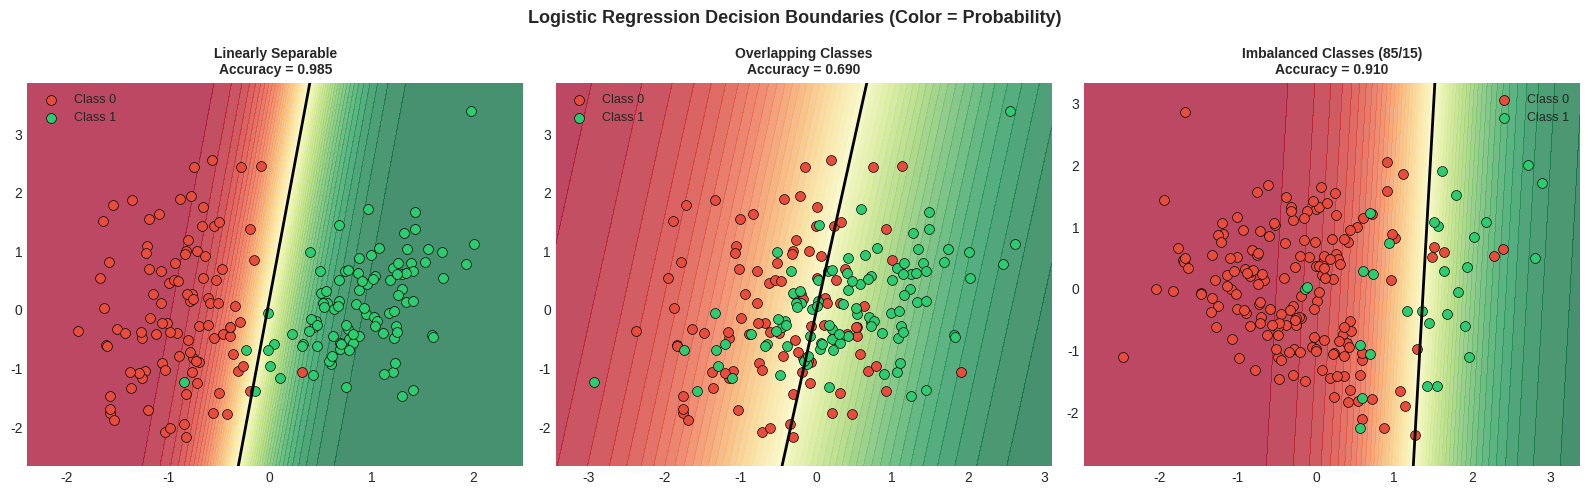

In [5]:
# Decision boundaries with different dataset complexities
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_decision_boundary(ax, X, y, model, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y==0,0], X[y==0,1], c='#E74C3C', s=50, edgecolors='k', lw=0.5, label='Class 0')
    ax.scatter(X[y==1,0], X[y==1,1], c='#2ECC71', s=50, edgecolors='k', lw=0.5, label='Class 1')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(False)

# Linearly separable
X1, y1 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, n_clusters_per_class=1, class_sep=2.0, random_state=42)
sc = StandardScaler()
X1s = sc.fit_transform(X1)
m1 = LogisticRegression().fit(X1s, y1)
plot_decision_boundary(axes[0], X1s, y1, m1,
    f'Linearly Separable\nAccuracy = {accuracy_score(y1, m1.predict(X1s)):.3f}')

# Overlapping classes
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, n_clusters_per_class=1, class_sep=0.5, random_state=42)
X2s = sc.fit_transform(X2)
m2 = LogisticRegression().fit(X2s, y2)
plot_decision_boundary(axes[1], X2s, y2, m2,
    f'Overlapping Classes\nAccuracy = {accuracy_score(y2, m2.predict(X2s)):.3f}')

# Imbalanced
X3, y3 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, weights=[0.85, 0.15], random_state=42)
X3s = sc.fit_transform(X3)
m3 = LogisticRegression().fit(X3s, y3)
plot_decision_boundary(axes[2], X3s, y3, m3,
    f'Imbalanced Classes (85/15)\nAccuracy = {accuracy_score(y3, m3.predict(X3s)):.3f}')

plt.suptitle('Logistic Regression Decision Boundaries (Color = Probability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='part-5'></a>
# Part 5: Binary Classification — Practical Example (Breast Cancer Dataset)

## 5.1 Dataset Overview

We use the **Wisconsin Breast Cancer dataset** (sklearn built-in), which contains 569 samples with 30 features describing cell nucleus characteristics. The task is to classify tumors as **malignant (0)** or **benign (1)**.

| Property | Value |
|----------|-------|
| Samples | 569 |
| Features | 30 (numeric) |
| Classes | 2 (Malignant=0, Benign=1) |
| Class distribution | 37.3% malignant, 62.7% benign |

In [6]:
# Load and explore the Breast Cancer dataset
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = bc.target

print('BREAST CANCER DATASET OVERVIEW')
print('='*50)
print(f'Shape: {X_bc.shape}')
print(f'Classes: {bc.target_names}')
print(f'Class distribution: {dict(zip(bc.target_names, np.bincount(y_bc)))}')
print('\nFirst 5 rows (selected features):')
print(X_bc[['mean radius','mean texture','mean perimeter','mean area','mean smoothness']].head())

# Train-test split and scaling
X_tr, X_te, y_tr, y_te = train_test_split(X_bc.values, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

# Train logistic regression
log_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
log_model.fit(X_tr_s, y_tr)

y_pred  = log_model.predict(X_te_s)
y_proba = log_model.predict_proba(X_te_s)[:,1]

print('\nMODEL PERFORMANCE ON TEST SET')
print('='*50)
print(classification_report(y_te, y_pred, target_names=bc.target_names))

BREAST CANCER DATASET OVERVIEW
Shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

First 5 rows (selected features):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        17.99         10.38          122.80     1001.0          0.11840
1        20.57         17.77          132.90     1326.0          0.08474
2        19.69         21.25          130.00     1203.0          0.10960
3        11.42         20.38           77.58      386.1          0.14250
4        20.29         14.34          135.10     1297.0          0.10030

MODEL PERFORMANCE ON TEST SET
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       11

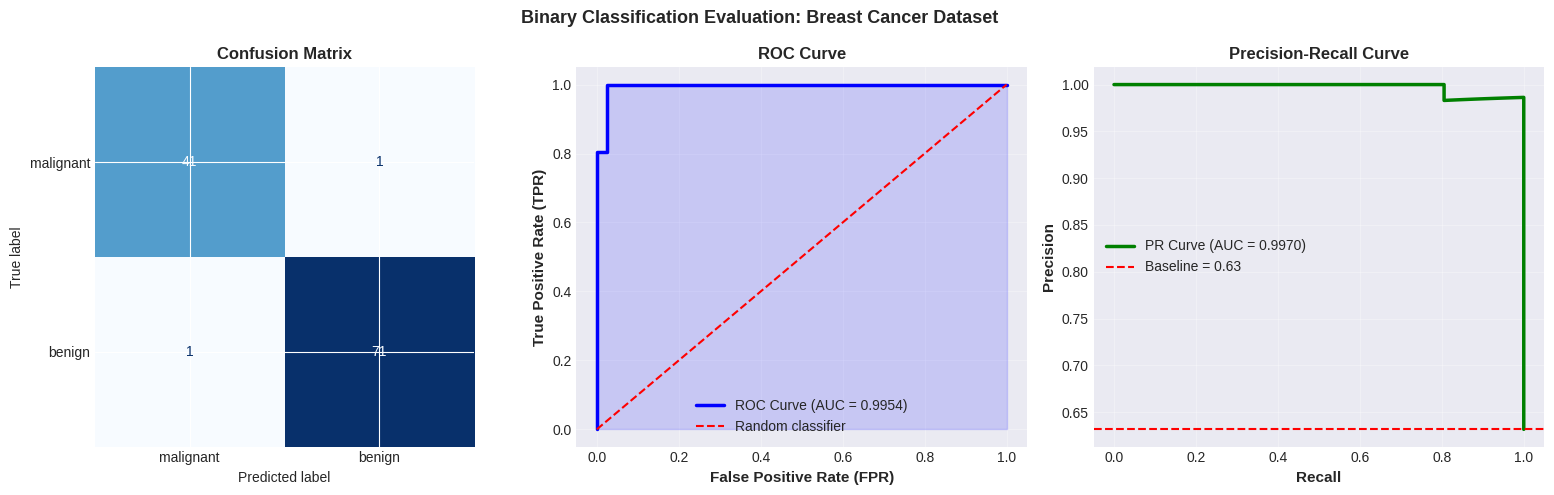

In [7]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bc.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_te, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'b-', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1],'r--',lw=1.5,label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11, fontweight='bold')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_te, y_proba)
pr_auc = auc(rec, prec)
axes[2].plot(rec, prec, 'g-', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[2].axhline(y_te.mean(), color='red', ls='--', lw=1.5, label=f'Baseline = {y_te.mean():.2f}')
axes[2].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

plt.suptitle('Binary Classification Evaluation: Breast Cancer Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

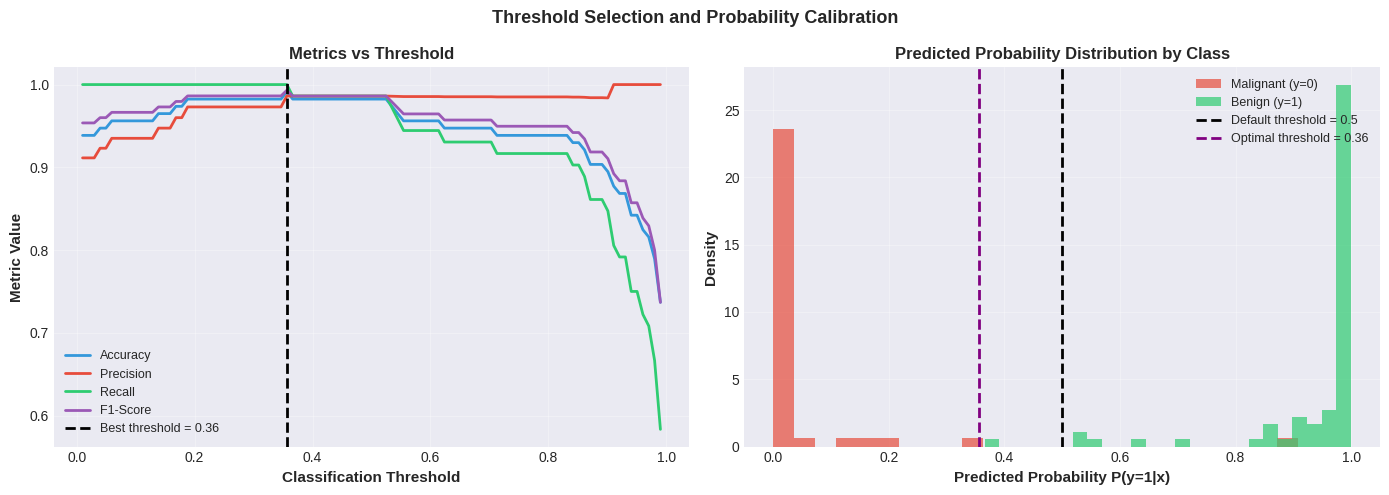

Optimal threshold (max F1): 0.3565
Max F1-Score: 0.9931


In [8]:
# Threshold analysis and probability calibration
thresholds_range = np.linspace(0.01, 0.99, 100)
accs, precs, recs, f1s = [], [], [], []
for t in thresholds_range:
    y_t = (y_proba >= t).astype(int)
    accs.append(accuracy_score(y_te, y_t))
    precs.append(precision_score(y_te, y_t, zero_division=0))
    recs.append(recall_score(y_te, y_t, zero_division=0))
    f1s.append(f1_score(y_te, y_t, zero_division=0))

best_t = thresholds_range[np.argmax(f1s)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_range, accs,  lw=2, label='Accuracy',  color='#3498DB')
axes[0].plot(thresholds_range, precs, lw=2, label='Precision', color='#E74C3C')
axes[0].plot(thresholds_range, recs,  lw=2, label='Recall',    color='#2ECC71')
axes[0].plot(thresholds_range, f1s,   lw=2, label='F1-Score',  color='#9B59B6')
axes[0].axvline(best_t, color='k', ls='--', lw=2, label=f'Best threshold = {best_t:.2f}')
axes[0].set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Metric Value', fontsize=11, fontweight='bold')
axes[0].set_title('Metrics vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Probability distribution by class
axes[1].hist(y_proba[y_te==0], bins=25, alpha=0.7, color='#E74C3C', label='Malignant (y=0)', density=True)
axes[1].hist(y_proba[y_te==1], bins=25, alpha=0.7, color='#2ECC71', label='Benign (y=1)',    density=True)
axes[1].axvline(0.5, color='k', ls='--', lw=2, label='Default threshold = 0.5')
axes[1].axvline(best_t, color='purple', ls='--', lw=2, label=f'Optimal threshold = {best_t:.2f}')
axes[1].set_xlabel('Predicted Probability P(y=1|x)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=11, fontweight='bold')
axes[1].set_title('Predicted Probability Distribution by Class', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Selection and Probability Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Optimal threshold (max F1): {best_t:.4f}')
print(f'Max F1-Score: {max(f1s):.4f}')

---
<a id='part-6'></a>
# Part 6: Multi-class Classification — Iris Dataset

## 6.1 Strategies for Multi-class Classification

Logistic regression can be extended to multi-class problems using:

- **One-vs-Rest (OvR):** Train $K$ binary classifiers, one per class. Each classifier distinguishes one class from all others. Predict the class with the highest confidence.
- **Softmax (Multinomial):** Extends logistic regression directly to $K$ classes using the softmax function:

$$P(y=k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T\mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T\mathbf{x}}}$$

| Strategy | Classifiers Trained | Probability Output | Best For |
|----------|--------------------|--------------------|----------|
| **One-vs-Rest** | $K$ | Not calibrated | Large $K$ |
| **Softmax** | 1 (joint) | Calibrated | Small-medium $K$ |

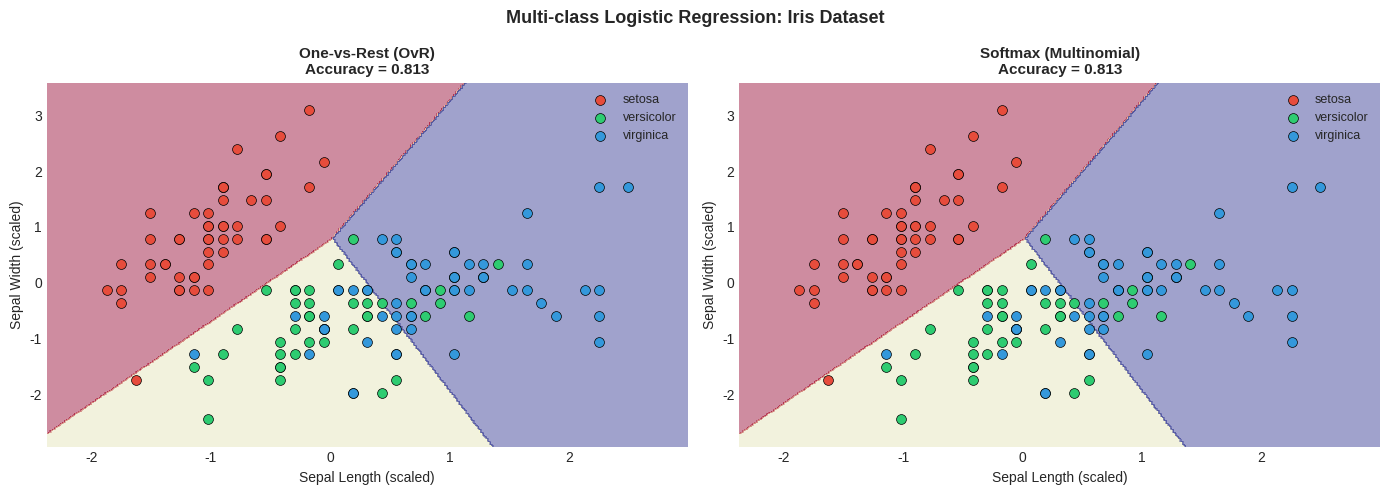

MULTI-CLASS CLASSIFICATION REPORT (Softmax, Iris Test Set)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.62      0.50      0.56        10
   virginica       0.58      0.70      0.64        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30



In [9]:
# Multi-class: Iris dataset
iris = load_iris()
X_ir = iris.data[:, :2]  # Use first 2 features for visualization
y_ir = iris.target
class_names = iris.target_names

sc_ir = StandardScaler()
X_ir_s = sc_ir.fit_transform(X_ir)
X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(X_ir_s, y_ir, test_size=0.2, random_state=42, stratify=y_ir)

# Train OvR and Softmax
ovr_model  = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_ir, y_tr_ir)
soft_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42).fit(X_tr_ir, y_tr_ir)

def plot_mc_boundary(ax, X, y, model, title, class_names):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    colors_bg = ['#FADBD8','#D5F5E3','#D6EAF8']
    colors_pt = ['#E74C3C','#2ECC71','#3498DB']
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.get_cmap('RdYlBu', 3))
    for k, (cn, cp) in enumerate(zip(class_names, colors_pt)):
        ax.scatter(X[y==k,0], X[y==k,1], c=cp, s=50, edgecolors='k', lw=0.5, label=cn)
    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f'{title}\nAccuracy = {acc:.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_mc_boundary(axes[0], X_ir_s, y_ir, ovr_model,  'One-vs-Rest (OvR)', class_names)
plot_mc_boundary(axes[1], X_ir_s, y_ir, soft_model, 'Softmax (Multinomial)', class_names)
axes[0].set_xlabel('Sepal Length (scaled)'); axes[0].set_ylabel('Sepal Width (scaled)')
axes[1].set_xlabel('Sepal Length (scaled)'); axes[1].set_ylabel('Sepal Width (scaled)')
plt.suptitle('Multi-class Logistic Regression: Iris Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Multi-class metrics
y_pred_mc = soft_model.predict(X_te_ir)
print('MULTI-CLASS CLASSIFICATION REPORT (Softmax, Iris Test Set)')
print('='*60)
print(classification_report(y_te_ir, y_pred_mc, target_names=class_names))

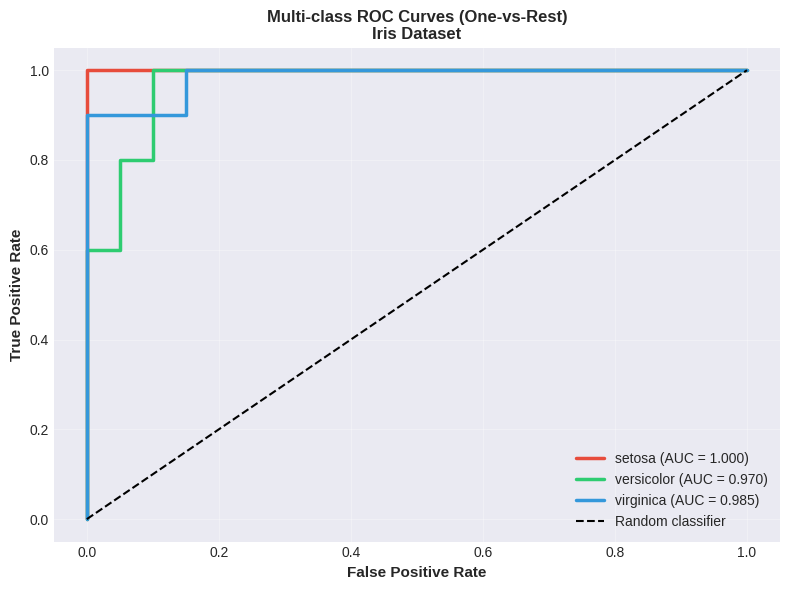

In [10]:
# Multi-class ROC curves (One-vs-Rest)
iris_full = load_iris()
X_full = iris_full.data; y_full = iris_full.target
sc_full = StandardScaler()
X_full_s = sc_full.fit_transform(X_full)
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_full_s, y_full, test_size=0.2, random_state=42, stratify=y_full)

y_te_bin = label_binarize(y_te_f, classes=[0,1,2])
ovr_full = OneVsRestClassifier(LogisticRegression(max_iter=1000)).fit(X_tr_f, y_tr_f)
y_score  = ovr_full.predict_proba(X_te_f)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#E74C3C','#2ECC71','#3498DB']
for k, (cn, col) in enumerate(zip(class_names, colors_roc)):
    fpr_k, tpr_k, _ = roc_curve(y_te_bin[:,k], y_score[:,k])
    auc_k = auc(fpr_k, tpr_k)
    ax.plot(fpr_k, tpr_k, color=col, lw=2.5, label=f'{cn} (AUC = {auc_k:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('Multi-class ROC Curves (One-vs-Rest)\nIris Dataset', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
<a id='part-7'></a>
# Part 7: Regularization in Logistic Regression

## 7.1 Regularized Logistic Regression

The regularized objective adds a penalty to the log-loss:

$$\mathcal{L}_{\text{reg}}(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right] + \lambda \Omega(\mathbf{w})$$

In sklearn, the parameter **C = 1/λ** (inverse of regularization strength):

| C value | Regularization | Bias | Variance |
|---------|---------------|------|----------|
| Small C (e.g., 0.001) | Strong | High | Low |
| C = 1.0 | Moderate | Med | Med |
| Large C (e.g., 1000) | Weak (≈ OLS) | Low | High |

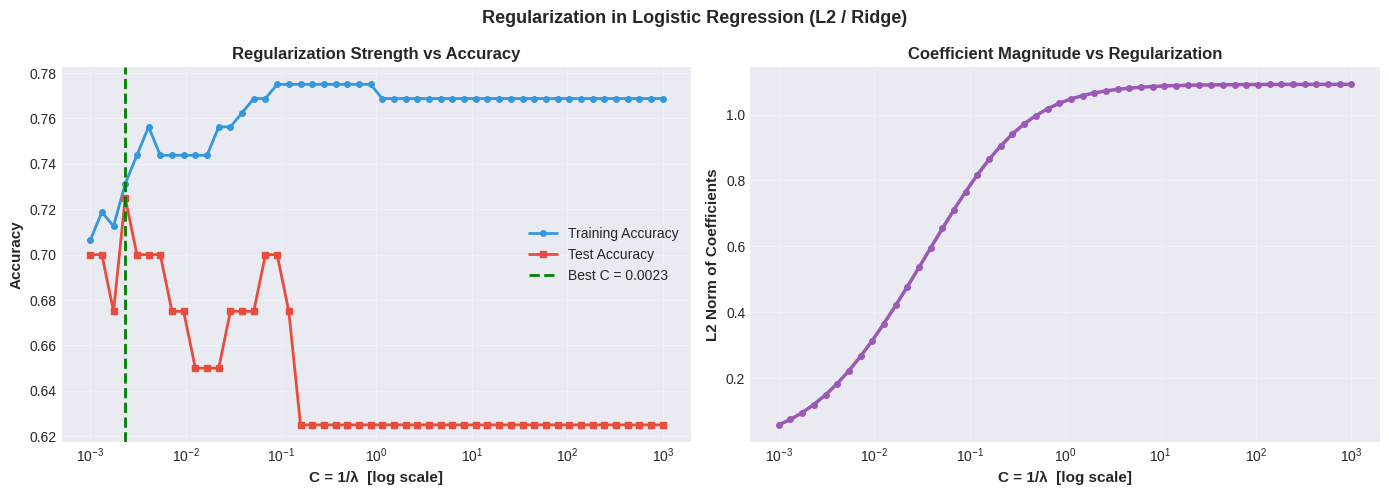

Best C = 0.002330  |  Best Test Accuracy = 0.7250


In [11]:
# Regularization effect on logistic regression
np.random.seed(42)
X_reg, y_reg = make_classification(n_samples=200, n_features=20, n_informative=5,
                                    n_redundant=5, random_state=42)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
sc_r = StandardScaler()
X_tr_rs = sc_r.fit_transform(X_tr_r)
X_te_rs  = sc_r.transform(X_te_r)

C_values = np.logspace(-3, 3, 50)
tr_accs, te_accs = [], []
l1_coef_norms, l2_coef_norms = [], []

for C in C_values:
    m_l2 = LogisticRegression(C=C, penalty='l2', max_iter=1000, random_state=42).fit(X_tr_rs, y_tr_r)
    tr_accs.append(accuracy_score(y_tr_r, m_l2.predict(X_tr_rs)))
    te_accs.append(accuracy_score(y_te_r, m_l2.predict(X_te_rs)))
    l2_coef_norms.append(np.linalg.norm(m_l2.coef_))

best_C = C_values[np.argmax(te_accs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_values, tr_accs, 'o-', lw=2, ms=4, label='Training Accuracy', color='#3498DB')
axes[0].semilogx(C_values, te_accs, 's-', lw=2, ms=4, label='Test Accuracy',     color='#E74C3C')
axes[0].axvline(best_C, color='green', ls='--', lw=2, label=f'Best C = {best_C:.4f}')
axes[0].set_xlabel('C = 1/λ  [log scale]', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Regularization Strength vs Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_values, l2_coef_norms, 'o-', lw=2.5, ms=4, color='#9B59B6')
axes[1].set_xlabel('C = 1/λ  [log scale]', fontsize=11, fontweight='bold')
axes[1].set_ylabel('L2 Norm of Coefficients', fontsize=11, fontweight='bold')
axes[1].set_title('Coefficient Magnitude vs Regularization', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Regularization in Logistic Regression (L2 / Ridge)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best C = {best_C:.6f}  |  Best Test Accuracy = {max(te_accs):.4f}')

---
<a id='part-8'></a>
# Part 8: Model Evaluation & Validation

## 8.1 Classification Metrics Summary

Given the confusion matrix with TP, TN, FP, FN:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | $(TP+TN)/(TP+TN+FP+FN)$ | Overall correctness |
| **Precision** | $TP/(TP+FP)$ | Of predicted positives, how many are correct |
| **Recall (Sensitivity)** | $TP/(TP+FN)$ | Of actual positives, how many detected |
| **Specificity** | $TN/(TN+FP)$ | Of actual negatives, how many detected |
| **F1-Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Harmonic mean of Precision and Recall |
| **AUC-ROC** | Area under ROC curve | Discrimination ability across thresholds |

## 8.2 K-Fold Cross-Validation for Hyperparameter Tuning

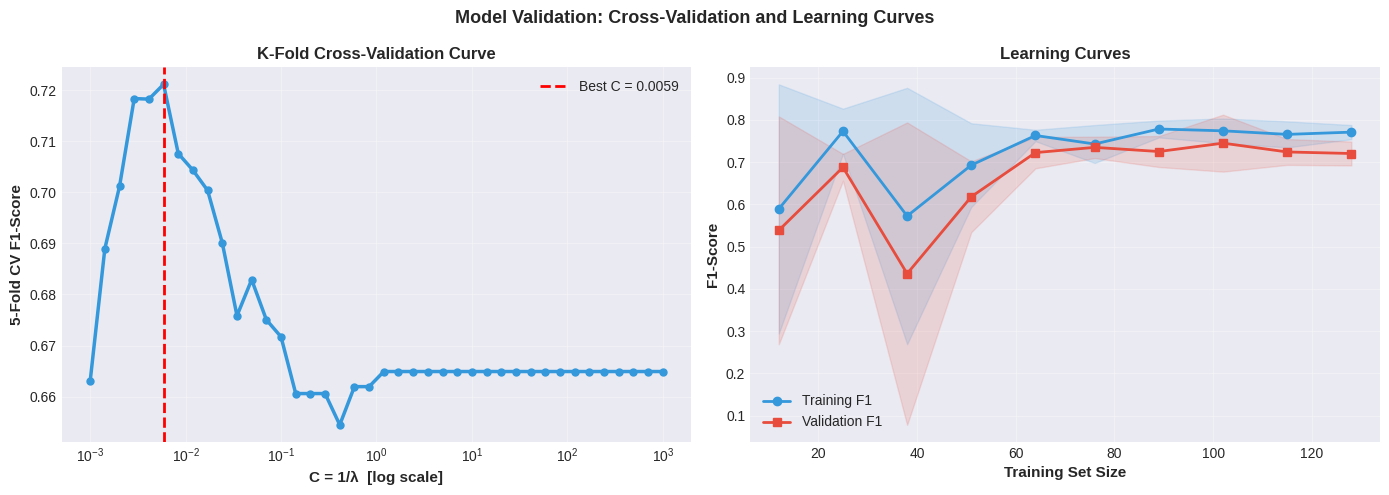

Best C (CV) = 0.005878  |  Best CV F1 = 0.7211


In [12]:
# K-fold CV for C selection
kf = KFold(n_splits=5, shuffle=True, random_state=42)
C_vals = np.logspace(-3, 3, 40)
cv_scores = []
for C in C_vals:
    scores = cross_val_score(
        LogisticRegression(C=C, max_iter=1000, random_state=42),
        X_tr_rs, y_tr_r, cv=kf, scoring='f1'
    )
    cv_scores.append(scores.mean())

best_C_cv = C_vals[np.argmax(cv_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_vals, cv_scores, 'o-', lw=2.5, ms=5, color='#3498DB')
axes[0].axvline(best_C_cv, color='red', ls='--', lw=2, label=f'Best C = {best_C_cv:.4f}')
axes[0].set_xlabel('C = 1/λ  [log scale]', fontsize=11, fontweight='bold')
axes[0].set_ylabel('5-Fold CV F1-Score', fontsize=11, fontweight='bold')
axes[0].set_title('K-Fold Cross-Validation Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Learning curves
best_model = LogisticRegression(C=best_C_cv, max_iter=1000, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_tr_rs, y_tr_r, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
tr_mean = train_scores.mean(axis=1); tr_std = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1);   va_std = val_scores.std(axis=1)

axes[1].plot(train_sizes, tr_mean, 'o-', lw=2, color='#3498DB', label='Training F1')
axes[1].fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#3498DB')
axes[1].plot(train_sizes, va_mean, 's-', lw=2, color='#E74C3C', label='Validation F1')
axes[1].fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#E74C3C')
axes[1].set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1].set_title('Learning Curves', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Validation: Cross-Validation and Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best C (CV) = {best_C_cv:.6f}  |  Best CV F1 = {max(cv_scores):.4f}')

---
<a id='part-9'></a>
# Part 9: Assumptions & Diagnostics

## 9.1 Key Assumptions of Logistic Regression

| Assumption | Description | How to Check |
|-----------|-------------|-------------|
| **Binary/ordinal outcome** | Response must be categorical | Check target variable |
| **Independence** | Observations are independent | Study design |
| **No multicollinearity** | Features should not be highly correlated | Correlation matrix, VIF |
| **Linearity of log-odds** | Log-odds must be linear in features | Box-Tidwell test |
| **Large sample size** | At least 10 events per feature | Check N/p ratio |

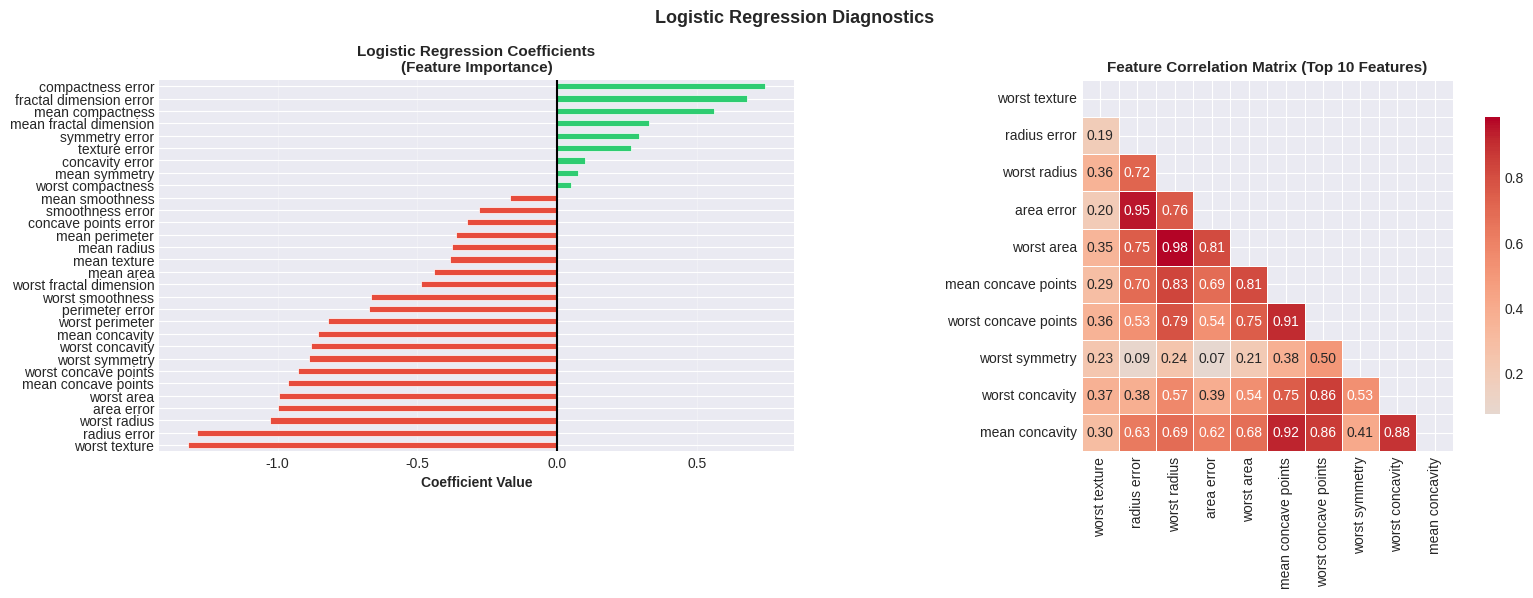

In [13]:
# Diagnostics: Feature importance and correlation
bc2 = load_breast_cancer()
X_bc2 = pd.DataFrame(bc2.data, columns=bc2.feature_names)
y_bc2 = bc2.target
sc2 = StandardScaler()
X_bc2_s = sc2.fit_transform(X_bc2)
final_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(X_bc2_s, y_bc2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient importance
coefs = pd.Series(final_model.coef_[0], index=bc2.feature_names).sort_values()
colors_coef = ['#E74C3C' if c < 0 else '#2ECC71' for c in coefs]
coefs.plot(kind='barh', ax=axes[0], color=colors_coef, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='k', lw=1.5)
axes[0].set_title('Logistic Regression Coefficients\n(Feature Importance)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Coefficient Value', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Correlation heatmap (top 10 features)
top10 = np.abs(coefs).nlargest(10).index
corr_matrix = X_bc2[top10].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, mask=mask, cbar_kws={'shrink':0.8})
axes[1].set_title('Feature Correlation Matrix (Top 10 Features)', fontsize=11, fontweight='bold')

plt.suptitle('Logistic Regression Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='summary'></a>
# Summary and Key Takeaways

| Topic | Core Idea | Key Formula |
|-------|-----------|-------------|
| **Sigmoid** | Maps any real number to (0,1) | $\sigma(z) = 1/(1+e^{-z})$ |
| **Log-odds** | Linear function of features | $\log(p/(1-p)) = \mathbf{w}^T\mathbf{x}$ |
| **MLE** | Maximize log-likelihood | Minimize cross-entropy loss |
| **Decision boundary** | Hyperplane where P=0.5 | $\mathbf{w}^T\mathbf{x} + b = 0$ |
| **Regularization** | C = 1/λ controls strength | Small C = strong regularization |
| **Multi-class** | OvR or Softmax | Softmax: $P(k) = e^{z_k}/\sum e^{z_j}$ |
| **Evaluation** | Multiple metrics needed | Accuracy, F1, AUC-ROC |

## Best Practices

1. Always **standardize features** before training.
2. Use **cross-validation** to select the optimal C.
3. For **imbalanced classes**, prefer F1-score and AUC-ROC over accuracy.
4. Tune the **classification threshold** based on the problem's cost of FP vs FN.
5. Check for **multicollinearity** using correlation matrices.
6. Use **L1 regularization** for feature selection, **L2** for stability.
7. Inspect **learning curves** to diagnose underfitting vs overfitting.

---
**Course:** DA5401W - Data Analytics Lab  |  **Instructor:** Dr. Arun B Ayyar